# (i)

We can approximate the value of the integral of a function using the Monte Carlo method in the (0,1) interval
$$
I = \int_0^1 f(x) dx \approx \frac{1}{N} \sum_{i=1}^{N} f(x_i)
$$
Where $x_i$ are uniformly distributed random numbers in the interval (0,1) and N is the number of samples, since
$$
E[f(x)] = \int_0^1 \dfrac{f(x)}{1} dx = \int_0^1 f(x) dx  \to \frac{1}{N} \sum_{i=1}^{N} f(x_i) \text{ for } n \to \infty.
$$
However, for the general interval we recall the the PDF of a uniform distribution in the interval (a,b) is given by
$$
g(x) = \frac{1}{b-a} \text{ for } x \in (a,b)
$$
so, if we let $X \sim U(a,b)$, then we have
$$
E[f(X)] = \int_a^b f(x) g(x) dx = \int_a^b f(x) \frac{1}{b-a} dx = \frac{1}{b-a} \int_a^b f(x) dx
$$
so
$$
\int_a^b f(x) dx = (b-a) E[f(X)] \approx (b-a) \frac{1}{N} \sum_{i=1}^{N} f(x_i)
$$

In [13]:
import numpy as np
from task4 import monte_carlo

f = lambda x: np.sin(x)
a = 0
b = np.pi
n  = 10000
sol = monte_carlo(f, n, a, b)
sol

np.float64(1.9989357817923807)

# (ii)
We sample from the uniform distribution in the interval (0,$\pi$) and we see how many of the samples are larger than a sample from $V \sim U(0,1)$. Note that we have to scale this by area of the rectangle $|\{(x,y) : x \in [0,\pi] \:\wedge \: y \in [0,1]\}|$, where $|S|$ is the lebesque measure of the set $S$.

In [14]:
def proportion(n):
    u = np.random.uniform(0,np.pi, n)
    v = np.random.uniform(0,1, n)
    sol = v < f(u)
    sol = np.mean(sol) * np.pi
    return sol


# (iii)
We can check which method is more accurate by comparing the results of the two methods with the exact value of the integral, which is 2, for large n.

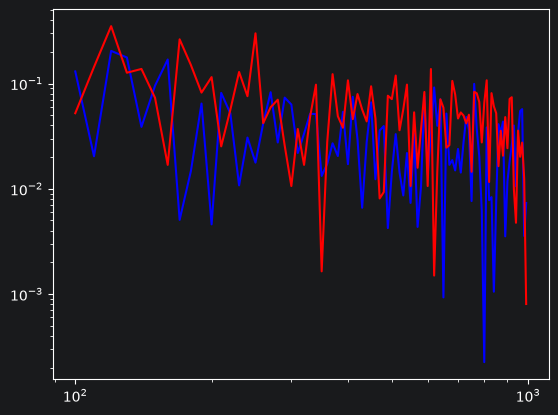

In [31]:
ns = np.arange(100, 1000,10)
error_monte_carlo = [abs(2-monte_carlo(f, n, a, b)) for n in ns]
error_proportion = [abs(2-proportion(n)) for n in ns]
import matplotlib.pyplot as plt
plt.loglog(ns, error_monte_carlo, label="Monte Carlo", color="blue")
plt.loglog(ns, error_proportion, label="Proportion", color="red")

In [17]:
ns

array([ 100,  200,  300,  400,  500,  600,  700,  800,  900, 1000, 1100,
       1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200,
       2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300,
       3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400,
       4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500,
       5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600,
       6700, 6800, 6900, 7000, 7100, 7200, 7300, 7400, 7500, 7600, 7700,
       7800, 7900, 8000, 8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800,
       8900, 9000, 9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900])